PROBLEM 1: Simple Sampling

In [1]:
import numpy as np
from scipy.stats import norm

def uniform_sampling(min_val, max_val, sample_size):
	"""
	Samples from a uniform distribution.

	Args:
		min_val (float): Minimum value of the uniform distribution.
		max_val (float): Maximum value of the uniform distribution.
		sample_size (int): Number of samples to generate.

	Returns:
		np.ndarray: Array of samples from the uniform distribution.
	"""
	return min_val + (max_val - min_val) * np.random.rand(sample_size)

def gaussian_sampling(mu, sigma, sample_size):
	"""
	Samples from a Gaussian distribution.

	Args:
		mu (float): Mean of the Gaussian distribution.
		sigma (float): Standard deviation of the Gaussian distribution.
		sample_size (int): Number of samples to generate.

	Returns:
		np.ndarray: Array of samples from the Gaussian distribution.
	"""
	return mu + sigma * np.random.randn(sample_size)

def gaussian_2d_sampling(mu, sigma, sample_size):
	"""
	Samples from a 2D Gaussian distribution.

	Args:
		mu (np.ndarray): Mean vector of the 2D Gaussian distribution (size 2).
		sigma (np.ndarray): Covariance matrix of the 2D Gaussian distribution (size 2x2).
		sample_size (int): Number of samples to generate.

	Returns:
		np.ndarray: Array of samples from the 2D Gaussian distribution (size sample_size x 2).
	"""
	# Perform Cholesky decomposition of the covariance matrix
	L = np.linalg.cholesky(sigma)
	# Generate independent standard normal samples
	z = np.random.randn(sample_size, 2)
	# x = μ + Lz where L is the Cholesky factor
	samples = np.dot(z, L.T) + mu
	
	return samples

def discrete_sampling_without_replacement(probabilities, sample_size):
	"""
	Samples from a discrete non-uniform distribution without replacement using Steven's method.

	Args:
		probabilities (np.ndarray): Array of probabilities for each element in the population.
		sample_size (int): Number of samples to generate.

	Returns:
		np.ndarray: Array of indices representing the sampled elements.
	"""
	n = len(probabilities)
	indices = np.arange(n)
	sampled_indices = []
	
	for _ in range(sample_size):
		# Normalize probabilities for the remaining elements
		probabilities = probabilities / np.sum(probabilities)
		
		# Sample an index based on the probabilities
		sampled_index = np.random.choice(indices, p=probabilities)
		
		# Add the sampled index to the list of sampled indices
		sampled_indices.append(sampled_index)
		
		# Remove the sampled index and its probability from consideration
		probabilities[sampled_index] = 0

	return np.array(sampled_indices)

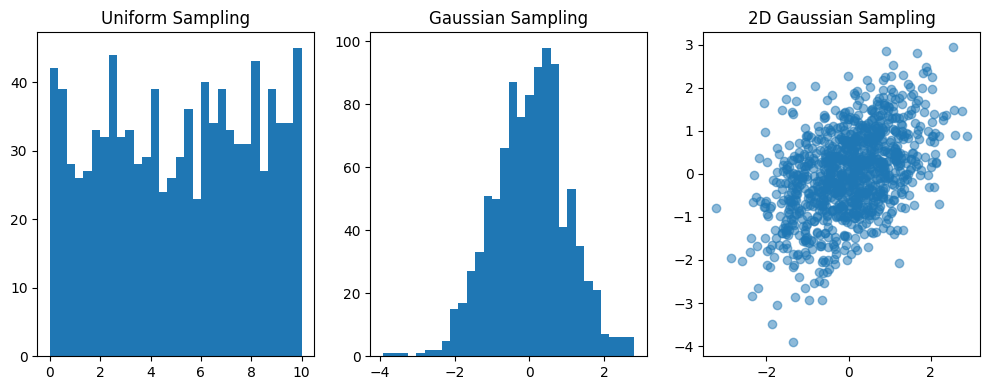

In [2]:
# Example usage of sampling methods from Problem 1
import numpy as np
import matplotlib.pyplot as plt

# Uniform sampling example
uniform_samples = uniform_sampling(0, 10, 1000)
plt.figure(figsize=(10, 4))
plt.subplot(131)
plt.hist(uniform_samples, bins=30)
plt.title('Uniform Sampling')

# Gaussian sampling example
gaussian_samples = gaussian_sampling(0, 1, 1000)
plt.subplot(132)
plt.hist(gaussian_samples, bins=30)
plt.title('Gaussian Sampling')

# 2D Gaussian sampling example
mu_2d = np.array([0, 0])
sigma_2d = np.array([[1, 0.5], [0.5, 1]])
samples_2d = gaussian_2d_sampling(mu_2d, sigma_2d, 1000)
plt.subplot(133)
plt.scatter(samples_2d[:, 0], samples_2d[:, 1], alpha=0.5)
plt.title('2D Gaussian Sampling')
plt.tight_layout()
plt.show()

PROBLEM 2: Conditional Sampling

In [3]:
def gibbs_sampling_2d_gaussian(mu, sigma, sample_size, initial_state=None):
	"""
	Performs Gibbs sampling for a 2D Gaussian distribution.

	Args:
		mu (np.ndarray): Mean vector of the 2D Gaussian distribution (size 2).
		sigma (np.ndarray): Covariance matrix of the 2D Gaussian distribution (size 2x2).
		sample_size (int): Number of samples to generate.
		initial_state (np.ndarray, optional): Initial state for the Gibbs sampler (size 2). 
											   If None, a random initial state is used.

	Returns:
		np.ndarray: Array of samples from the 2D Gaussian distribution (size sample_size x 2).
	"""
	
	# Precompute conditional parameters for efficiency
	sigma_11 = sigma[0, 0]
	sigma_12 = sigma[0, 1]
	sigma_21 = sigma[1, 0]
	sigma_22 = sigma[1, 1]
	mu_1 = mu[0]
	mu_2 = mu[1]

	# Conditional variance and mean for X1 given X2
	var_x1_given_x2 = sigma_11 - (sigma_12 * sigma_21) / sigma_22
	beta_12 = sigma_12 / sigma_22

	# Conditional variance and mean for X2 given X1
	var_x2_given_x1 = sigma_22 - (sigma_21 * sigma_12) / sigma_11
	beta_21 = sigma_21 / sigma_11
	
	# Initialize the sampler
	if initial_state is None:
		x = np.random.randn(2)  # Random initial state
	else:
		x = initial_state.copy()

	samples = np.zeros((sample_size, 2))

	# Gibbs sampling iterations
	for i in range(sample_size):
		# Sample X1 given X2
		mu_x1_given_x2 = mu_1 + beta_12 * (x[1] - mu_2)
		x[0] = np.random.normal(mu_x1_given_x2, np.sqrt(var_x1_given_x2))

		# Sample X2 given X1
		mu_x2_given_x1 = mu_2 + beta_21 * (x[0] - mu_1)
		x[1] = np.random.normal(mu_x2_given_x1, np.sqrt(var_x2_given_x1))

		samples[i, :] = x

	return samples

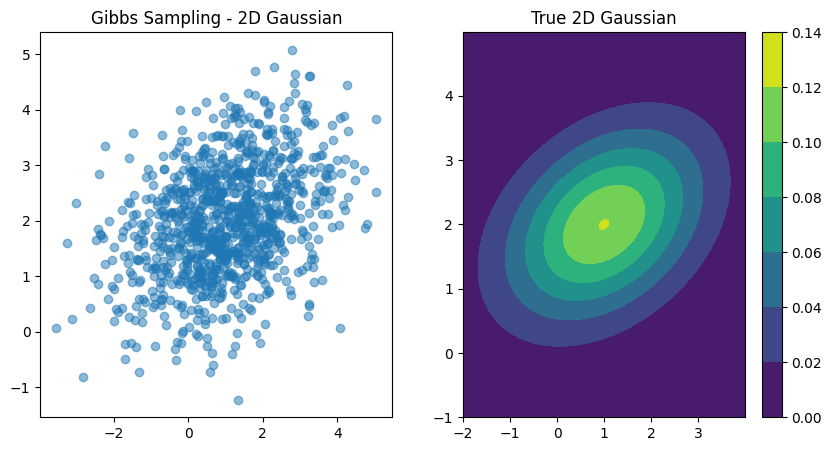

In [4]:
from scipy.stats import multivariate_normal

# Example usage of Gibbs sampling for 2D Gaussian
mu = np.array([1, 2])
sigma = np.array([[2, 0.5], [0.5, 1]])
samples = gibbs_sampling_2d_gaussian(mu, sigma, 1000)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.title('Gibbs Sampling - 2D Gaussian')

# Plot true distribution for comparison
x, y = np.mgrid[-2:4:.01, -1:5:.01]
pos = np.dstack((x, y))
rv = multivariate_normal(mu, sigma)
plt.subplot(122)
plt.contourf(x, y, rv.pdf(pos))
plt.title('True 2D Gaussian')
plt.colorbar()
plt.show()

PROBLEM 3: Implement your own baby-LDA

In [5]:
# Implementation of Baby-LDA
import numpy as np
from collections import defaultdict
import re
from typing import List, Dict, Tuple
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

class BabyLDA:
    def __init__(self, n_topics: int = 6, alpha: float = 5.0, beta: float = 2.0):
        self.n_topics = n_topics
        self.alpha = alpha
        self.beta = beta
        self.vocab = None
        self.vocab_size = None
        
    def preprocess_documents(self, documents: List[str]) -> List[List[int]]:
        """Preprocess documents and create vocabulary"""
        stop_words = set(stopwords.words('english'))
        word_count = defaultdict(int)
        processed_docs = []
        
        # First pass: count words
        for doc in documents:
            words = re.findall(r'\w+', doc.lower())
            for word in words:
                if (len(word) >= 3 and 
                    word not in stop_words and 
                    not word.isnumeric()):
                    word_count[word] += 1
        
        # Create vocabulary (excluding rare words)
        self.vocab = {word for word, count in word_count.items() if count >= 5}
        self.vocab_size = len(self.vocab)
        word_to_id = {word: idx for idx, word in enumerate(self.vocab)}
        
        # Second pass: convert to word indices
        for doc in documents:
            words = re.findall(r'\w+', doc.lower())
            doc_indices = [word_to_id[word] for word in words 
                         if word in word_to_id]
            if doc_indices:
                processed_docs.append(doc_indices)
        
        return processed_docs
    
    def initialize_counts(self, docs: List[List[int]]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[List[int]]]:
        """Initialize count matrices and topic assignments"""
        n_docs = len(docs)
        
        # Initialize count matrices
        doc_topic_counts = np.zeros((n_docs, self.n_topics)) + self.alpha
        topic_word_counts = np.zeros((self.n_topics, self.vocab_size)) + self.beta
        topic_totals = np.zeros(self.n_topics) + self.beta * self.vocab_size
        
        # Initialize topic assignments
        topic_assignments = []
        for d, doc in enumerate(docs):
            doc_topics = []
            for word_idx in doc:
                topic = np.random.randint(self.n_topics)
                doc_topics.append(topic)
                doc_topic_counts[d, topic] += 1
                topic_word_counts[topic, word_idx] += 1
                topic_totals[topic] += 1
            topic_assignments.append(doc_topics)
            
        return doc_topic_counts, topic_word_counts, topic_totals, topic_assignments
    
    def sample_topic(self, d: int, w: int, doc_topic_counts: np.ndarray, 
                    topic_word_counts: np.ndarray, topic_totals: np.ndarray) -> int:
        """Sample a new topic for a word"""
        p_topic = (doc_topic_counts[d] * topic_word_counts[:, w] / topic_totals)
        p_topic = p_topic / p_topic.sum()
        return np.random.choice(self.n_topics, p=p_topic)
    
    def fit(self, documents: List[str], n_iterations: int = 100):
        """Fit the LDA model using Gibbs sampling"""
        # Preprocess documents
        processed_docs = self.preprocess_documents(documents)
        
        # Initialize counts
        doc_topic_counts, topic_word_counts, topic_totals, topic_assignments = \
            self.initialize_counts(processed_docs)
        
        # Gibbs sampling iterations
        for _ in range(n_iterations):
            for d, (doc, doc_topics) in enumerate(zip(processed_docs, topic_assignments)):
                for i, (word_idx, topic) in enumerate(zip(doc, doc_topics)):
                    # Remove current topic assignment
                    doc_topic_counts[d, topic] -= 1
                    topic_word_counts[topic, word_idx] -= 1
                    topic_totals[topic] -= 1
                    
                    # Sample new topic
                    new_topic = self.sample_topic(d, word_idx, doc_topic_counts,
                                               topic_word_counts, topic_totals)
                    
                    # Update counts
                    doc_topic_counts[d, new_topic] += 1
                    topic_word_counts[new_topic, word_idx] += 1
                    topic_totals[new_topic] += 1
                    topic_assignments[d][i] = new_topic
        
        # Store the final state
        self.doc_topic_counts = doc_topic_counts
        self.topic_word_counts = topic_word_counts
        self.topic_totals = topic_totals
        
        return self
    
    def get_topic_words(self, n_words: int = 10) -> List[List[str]]:
        """Get the top n words for each topic"""
        topics = []
        vocab_list = list(self.vocab)
        
        for topic_idx in range(self.n_topics):
            word_probs = self.topic_word_counts[topic_idx] / self.topic_totals[topic_idx]
            top_words = [vocab_list[i] for i in word_probs.argsort()[-n_words:][::-1]]
            topics.append(top_words)
            
        return topics

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Topic 1:
love(0.066), doth(0.020), still(0.020), loves(0.017), thought(0.016), better(0.016), far(0.016), though(0.016)

Topic 2:
love(0.055), mine(0.041), eyes(0.035), heart(0.034), eye(0.028), doth(0.026), hath(0.021), true(0.019)

Topic 3:
doth(0.037), beauty(0.033), fair(0.028), sweet(0.025), praise(0.024), every(0.020), show(0.020), time(0.018)

Topic 4:
shall(0.057), time(0.042), make(0.028), life(0.026), times(0.024), away(0.021), night(0.017), earth(0.017)

Topic 5:
thy(0.173), thou(0.144), thee(0.099), art(0.030), thine(0.027), love(0.018), dost(0.017), yet(0.016)


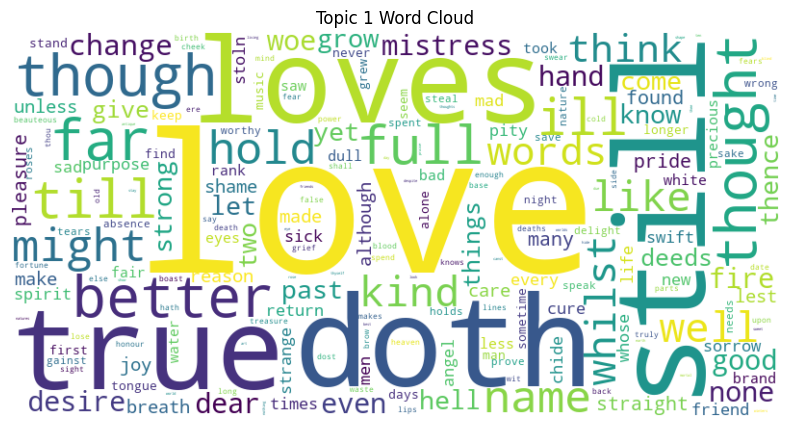

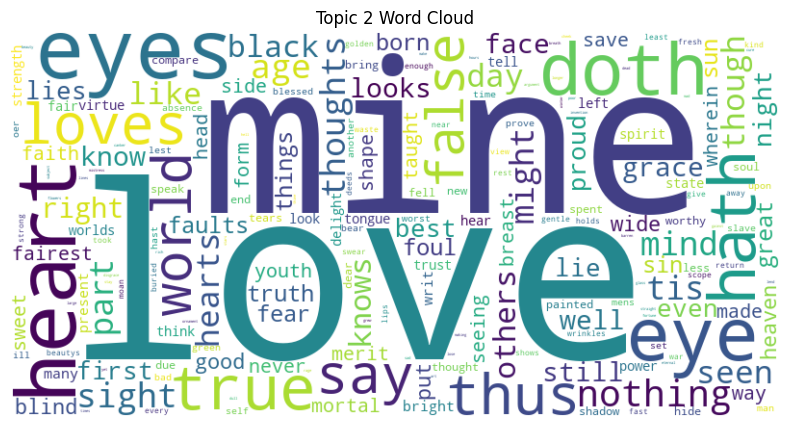

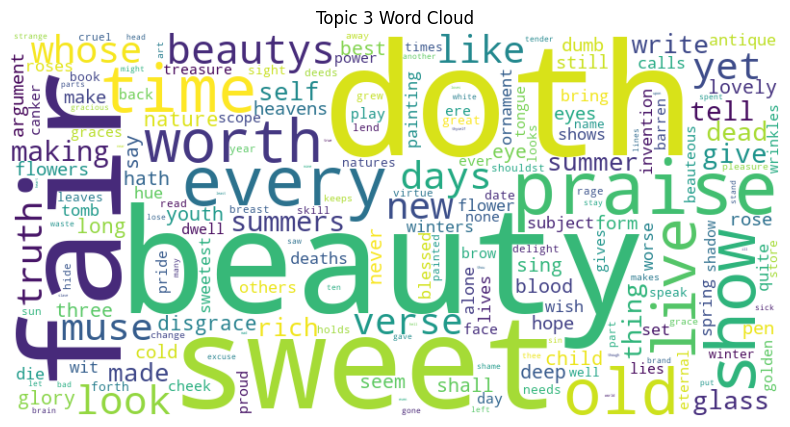

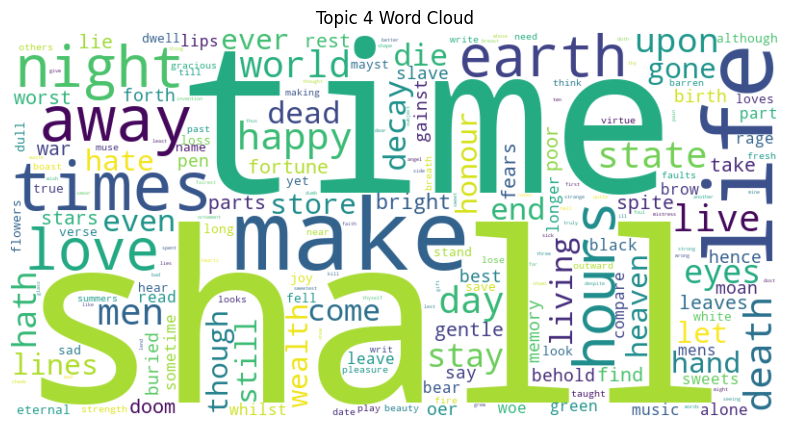

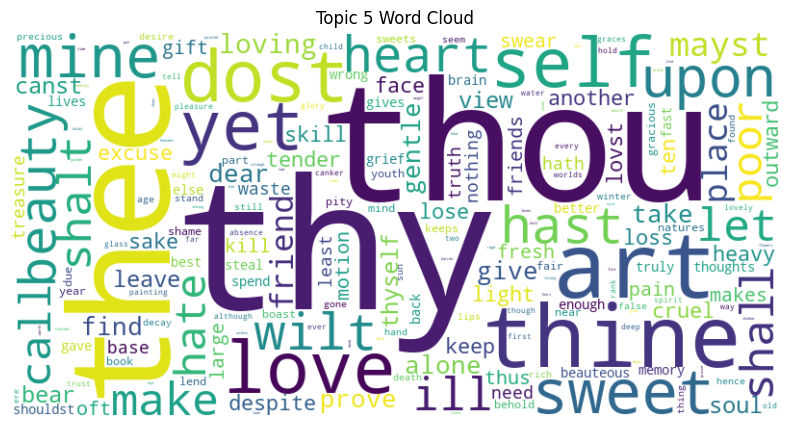

In [6]:
from wordcloud import WordCloud

# Load sonnets from file
with open('sonnetsPreprocessed.txt', 'r', encoding='utf-8') as f:
    sonnets = f.readlines()

# Clean sonnets - remove empty lines and strip whitespace
sonnets = [sonnet.strip() for sonnet in sonnets if sonnet.strip()]

# Initialize and fit the model
# Using more topics since sonnets have more diverse themes
lda = BabyLDA(n_topics=5, alpha=0.1, beta=0.1)  
lda.fit(sonnets, n_iterations=1000)  # More iterations for complex text

# Print top words for each topic with probabilities
topics = lda.get_topic_words(n_words=8)  # Showing more words per topic
for idx, topic_words in enumerate(topics):
    # Calculate word probabilities for this topic
    topic_probs = lda.topic_word_counts[idx] / lda.topic_totals[idx]
    top_indices = topic_probs.argsort()[-8:][::-1]
    
    # Format words with their probabilities
    word_prob_pairs = [f"{list(lda.vocab)[i]}({topic_probs[i]:.3f})" 
                       for i in top_indices]
    print(f"\nTopic {idx + 1}:")
    print(", ".join(word_prob_pairs))

# Generate and display a word cloud for each topic
for idx in range(len(topics)):  # Iterate over topics
    # Use word probabilities as weights
    word_freq = {list(lda.vocab)[i]: lda.topic_word_counts[idx, i] / lda.topic_totals[idx]
                 for i in range(lda.vocab_size)}
    
    # Create a word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
    
    # Plot the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Topic {idx + 1} Word Cloud')
    plt.show()

In [1]:
print("Hello moto")

Hello moto
